#  Masking Pipeline

## CHX Olog Logbook
CHX Olog (https://logbook.nsls2.bnl.gov/11-ID/) [requires VPN from offsite]


In [9]:
from pyCHX.chx_packages import *
%matplotlib notebook
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })
import pickle as cpk
from pyCHX.chx_xpcs_xsvs_jupyter_V1 import *
from pyCHX.chx_generic_functions import RemoveHot,create_multi_rotated_rectangle_mask
import json

%run /nsls2/data/chx/shared/CHX_Software/packages/environment_management/chx_analysis_setup_test_pyCHX.ipynb
_base_path_ = _base_path_pass_
print(colored("--> overwrote '_base_path_' as %s"%_base_path_,'cyan'))

running on: jupyter_hub   environment: standard

setting '_base_path_' as /nsls2/data/chx/legacy/analysis/
setting '_base_path_pass_' as /nsls2/data/chx/proposals/
setting '_mask_path_' as /nsls2/data/chx/shared/CHX_Setup/Detector_masks/

Re-imported pyCHX from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/
Re-imported chx_compress from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_compress.py
Re-imported chx_olog functions from  /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_olog.py

environment dependent settings and patches:
using "%matplotlib inline" for plotting
--> overwrote '_base_path_' as /nsls2/data/chx/proposals/


### Path for Saving Results

### Select the image series to create a mask

In [2]:
uid = '9d074654' #(scan num: 141284) (Measurement: single image for mask )

In [3]:
md = get_meta_data( uid )
cycle= md['cycle'] 
username = md['user']

## Can overwrite user and cycle below, if the metadata is not correct:
# cycle = ''
# user = ''

In [4]:
path = '%s/%s/%s/masks/'%(_base_path_,cycle,username)
print ("The mask will be saved in : %s"%path)
det_mask_path = _mask_path_+'pixel_masks/'   #'%s/masks/'%(_base_path_)
print('looking for detector mask in %s'%det_mask_path)

The mask will be saved in : /nsls2/data/chx/legacy/analysis//2023_3/CHX staff/masks/
looking for detector mask in /nsls2/data/chx/shared/CHX_Setup/Detector_masks/pixel_masks/


In [5]:
detector = get_detector( db[uid ] )
print ('Detector is:  %s'%detector  )
sud = get_sid_filenames(db[uid])
print ('scan_id, full-uid, data path are:  %s--%s--%s'%(sud[0], sud[1], sud[2][0] ))

## image rotations from analysis pipeline:
if md['detector'] =='eiger4m_single_image' or md['detector'] == 'image':    
    reverse= True
    rot90= False
elif md['detector'] =='eiger500K_single_image':    
    reverse= True
    rot90=True
elif md['detector'] =='eiger1m_single_image':    
    reverse= True
    rot90=False
print('detector: %s -> Image reverse: %s, Image rotate 90: %s'%(md['detector'].split('_')[0],reverse, rot90))

Detector is:  eiger4m_single_image


KeyError: 'data path'

In [ ]:
imgs = load_data( uid, detector, reverse= reverse, rot90=rot90  )
md.update( imgs.md );Nimg = len(imgs);
md['number of images']  = Nimg
pixel_mask=np.ones( np.shape(imgs[0]))
print( 'The data are: %s' %imgs )
print(md['beam_center_x'],md['beam_center_y'])
if reverse and not rot90:
    md['beam_center_y']=np.shape(imgs[0])[0]- md['beam_center_y']
    print(md['beam_center_y'])
if reverse and rot90:
    xc=md['beam_center_y'];yc=md['beam_center_x']
    yc=np.shape(imgs[0])[0]-yc
    xc=np.shape(imgs[0])[1]-xc
    print(xc,yc)
    md['beam_center_y']=yc;md['beam_center_x']=xc
if rot90 and not reverse:
    raise Exception('ERROR: somebody still needs to figure out the transformation for reverse=%s and rot90=%s!'%(reverse,rot90))

### Get the detector mask created by Detector_masks....ipynb

In [ ]:
detector_ = md['detector'].split('_')[0];det_mask_file = det_mask_path+'detector_mask_%s.json'%detector_
try: 
    json_open=open(det_mask_file)
    det_mask_dict=json.load(json_open)
    det_mask_dict.keys()
    print('loading detector mask: '+det_mask_file)
except:
    raise Exception('ERROR: detector mask file %s not found!'%det_mask_file)
fig,ax = plt.subplots(1,4,figsize=(20,5))
plt.suptitle('detector: %s   detector mask file: %s'%(detector_,det_mask_file))

for kk,k in enumerate(list(det_mask_dict['masks'].keys())):
    plt.subplot(1,4,kk+1)
    plt.title(k)
    plt.imshow( det_mask_dict['masks'][k])
    pixel_mask*=det_mask_dict['masks'][k]
plt.subplot(1,4,4)
plt.title('combined')
plt.imshow(pixel_mask)
masked=np.nonzero(np.array(pixel_mask)+~np.array(det_mask_dict['masks']['chip_mask'])<1)
#cmap = plt.cm.get_cmap('viridis')
cmap=plt.colormaps['viridis']
plt.plot(masked[1],masked[0],'+',color=cmap(0))


### show image and the combined detector mask

In [ ]:
img_choice_N = 1  #can change this number to select more frames for average
img_samp_index = random.sample( range(len(imgs)), img_choice_N) 
avg_img =  get_avg_img( imgs, img_samp_index, plot_ = False, uid = uid)
show_img(  avg_img*pixel_mask , vmin=.01, vmax=1e3, logs=True,
         image_name ='uid=%s'%uid, aspect=1, cmap= cmap_albula  )
plt.plot(md['beam_center_x'],md['beam_center_y'],'bo')

# Create polygon masks -> these are masked regions like the beamstop that should be 'attached' to the direct beam position
## polygon mask is NOT depending on the detector (Eiger4M or Eiger500k)

In [6]:
polygon_dict = {'uid':md['uid'],'masks':{}}  # start dictionary to collect all information to create polygon mask

## Create a rotated region

In [7]:
if False:
    length=[2000,2000];width=[10,20];angles=[10,60] 
    
    if len(length) ==1 and len(angles)>1: # multiple angles, all masks with same length
        length=list(np.ones(len(angles))*length)
    if len(width) ==1 and len(angles)>1: # multiple angles, all masks with same width
        width=list(np.ones(len(angles))*width)
    print('agnles: %s\nlengths: %s\nwidths: %s'%(angles,length, width))
    polygon_dict['masks']['rmask']={'length':length,'width':width,'angles':angles}

    rmask_dict={}
    for aa,a in enumerate(angles):
        rmask_dict[a] = create_multi_rotated_rectangle_mask( imgs[0], 
                                center= [ md['beam_center_x'], md['beam_center_y']   ], length=length[aa], width=width[aa], angles=[a] )

    for aa,a in enumerate(list(rmask_dict.keys())):
        if aa == 0:
            rmask = rmask_dict[a]
        else:
            rmask*=rmask_dict[a]
    show_img(avg_img*pixel_mask*rmask,vmin=0.1e-0,vmax=1e4, logs=True, 
         image_name= 'uid= %s with pixel mask'%uid , aspect=1, cmap= cmap_albula  )

### To create multi-rectangle masks, for each sub-mask



#### create the right part mask

if '4m' in md['detector']:
    partial_mask = create_cross_mask(  avg_img, center=[md['beam_center_x']- 100, md['beam_center_y']+50  ], #center=[509,185],
                            wy_left= 0, wy_right= 60, 
                              wx_up= 0, wx_down= 0,center_radius= 0 )
    ##for GiSAXS
    #partial_mask = create_cross_mask(  avg_img, center=[md['beam_center_x']- 200, 
    #                                                    md['beam_center_y']  ], #center=[509,185],
    #                        wy_left= 0, wy_right= 79, 
    #                          wx_up= 0, wx_down= 0,center_radius= 0 )    
    
elif '500K' in md['detector']:
    partial_mask = create_cross_mask(  avg_img, center=[md['beam_center_x']+60 , md['beam_center_y']+50  ], #center=[509,185],
                               wy_left= 0, wy_right= 0, 
                               wx_up= 0, wx_down= 35,center_radius= 0 )
else:
    print('Please check the detectors.')



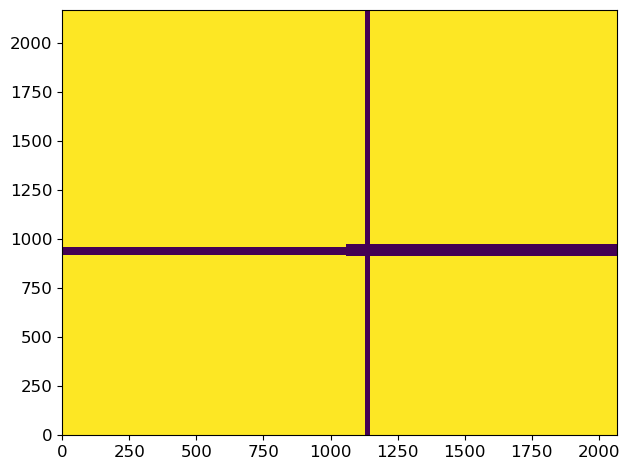

In [11]:
if True:
    x_off = [0,-80]
    y_off = [0,0]
    wy_left = [20,0]
    wy_right = [10,30]
    wx_up = [10,0]
    wx_down = [10,0]
    center_radius = [0,0]

    polygon_dict['masks']['partial_mask']={'x_off':x_off,'y_off':y_off,'wy_left':wy_left,'wy_right':wy_right,'wx_up':wx_up,'wx_down':wx_down,'center_radius':center_radius}
    partialmask_dict={}
    for ii,i in enumerate(range(len(x_off))[:]): # [:] use all elements in list; [:2] use the first two elements in list, etc. to create masks
        partialmask_dict[ii] = create_cross_mask(  avg_img,center= [ md['beam_center_x']+x_off[i], md['beam_center_y']+y_off[i]   ], 
                                wy_left= wy_left[i], wy_right= wy_right[i], 
                                wx_up= wx_up[i], wx_down= wx_down[i],center_radius= center_radius[i])
        
    for ii,i in enumerate(list(partialmask_dict.keys())):
        if ii == 0:
            partial_mask = partialmask_dict[i]
        else:
            partial_mask*=partialmask_dict[i]
    show_img(  partial_mask, show_colorbar=False   )


### create a circular mask for windows

In [12]:
if False:
    center_radius=980
    window_shadow  = ~create_cross_mask(  avg_img, center=[md['beam_center_x'],md['beam_center_y']],
                           wy_left= 0, wy_right= 0, 
                             wx_up= 0, wx_down= 0,center_disk=True, center_radius= center_radius)
    polygon_dict['masks']['window_mask']={'center_radius':center_radius}
else:
    try:
        polygon_dict['masks'].pop('window_mask')
    except: pass

## Test: re-create multi-polygon mask:

In [13]:
polygon_mask=np.ones_like( pixel_mask , dtype = bool)
if 'rmask' in list(polygon_dict['masks'].keys()):
    rmask_dict={}
    for aa,a in enumerate(polygon_dict['masks']['rmask']['angles']):
        rmask_dict[a] = create_multi_rotated_rectangle_mask( pixel_mask, 
                                center= [ md['beam_center_x'], md['beam_center_y']   ], length=polygon_dict['masks']['rmask']['length'][aa], width=polygon_dict['masks']['rmask']['width'][aa], angles=[a] )

    for aa,a in enumerate(list(rmask_dict.keys())):
        if aa == 0:
            rmask = rmask_dict[a]
        else:
            rmask*=rmask_dict[a]
    polygon_mask*=rmask
if 'partial_mask' in list(polygon_dict['masks'].keys()):
    partialmask_dict={}
    for ii,i in enumerate(range(len(polygon_dict['masks']['partial_mask']['x_off']))[:]): # [:] use all elements in list; [:2] use the first two elements in list, etc. to create masks
        partialmask_dict[ii] = create_cross_mask(  pixel_mask,center= [ md['beam_center_x']+polygon_dict['masks']['partial_mask']['x_off'][i], md['beam_center_y']+polygon_dict['masks']['partial_mask']['y_off'][i]   ], 
                                wy_left= polygon_dict['masks']['partial_mask']['wy_left'][i], wy_right= polygon_dict['masks']['partial_mask']['wy_right'][i], 
                                wx_up= polygon_dict['masks']['partial_mask']['wx_up'][i], wx_down= polygon_dict['masks']['partial_mask']['wx_down'][i],center_radius= polygon_dict['masks']['partial_mask']['center_radius'][i])
        
    for i in list(partialmask_dict.keys()):
        if i == 0:
            partial_mask = partialmask_dict[i]
        else:
            partial_mask*=partialmask_dict[i]
    polygon_mask*=partial_mask
if 'window_mask' in list(polygon_dict['masks'].keys()):
    window_shadow  = ~create_cross_mask(  pixel_mask, center=[md['beam_center_x'],md['beam_center_y']],
                           wy_left= 0, wy_right= 0, 
                             wx_up= 0, wx_down= 0,center_disk=True, center_radius= polygon_dict['masks']['window_mask']['center_radius'])
    polygon_mask*=window_shadow

(600.0, 1300.0)

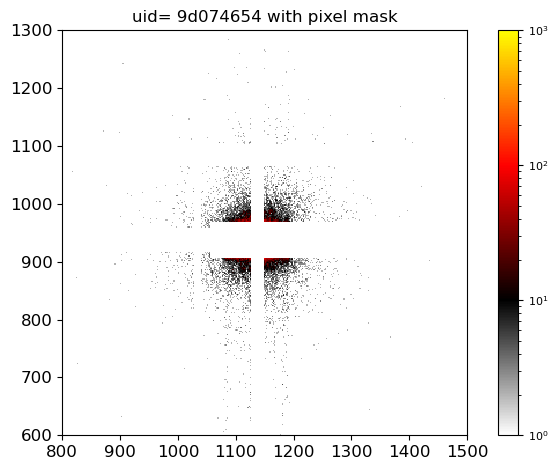

In [14]:
show_img(avg_img*pixel_mask*polygon_mask,vmin=1e-0,vmax=1e3, logs=True, 
         image_name= 'uid= %s with pixel mask'%uid , aspect=1, cmap= cmap_albula  )
plt.xlim(800,1500);plt.ylim(600,1300)

## Check for additional hot pixels e.g. around the direct beam position (best done with an 'empty' image (no sample)!!)

values above 100 : [112. 190. 215. 130.]
number of elements above 100: 0


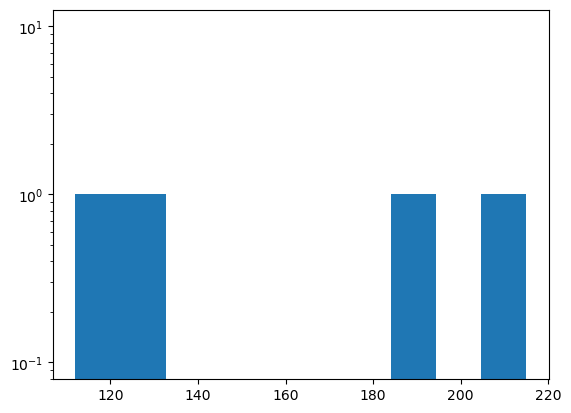

In [15]:
second_check=False
if True:
    thresh=100
    x=avg_img*pixel_mask*polygon_mask
    print('values above %s : %s'%(thresh,x[x>thresh]))
    print('number of elements above %s: %s'%(thresh,len(x[x>5000])))
    p=plt.hist(x[x>thresh])
    plt.yscale('log')
    second_check=True

In [16]:
if second_check:
    thresh=6000
    hots=np.nonzero(x > thresh)
    polygon_dict['masks']['hot_beam']={'x_hots':(hots[0]-md['beam_center_x']).tolist(),'y_hots':(hots[1]-md['beam_center_y']).tolist()}

In [17]:
if 'hot_beam'in list(polygon_dict['masks'].keys()):
    for i in range(len( polygon_dict['masks']['hot_beam']['x_hots'])):
        if polygon_dict['masks']['hot_beam']['x_hots'][i]+md['beam_center_x'] > 0 and polygon_dict['masks']['hot_beam']['y_hots'][i]+md['beam_center_y'] > 0:
            polygon_mask[int(polygon_dict['masks']['hot_beam']['x_hots'][i]+md['beam_center_x']),int(polygon_dict['masks']['hot_beam']['y_hots'][i]+md['beam_center_x'])]=0

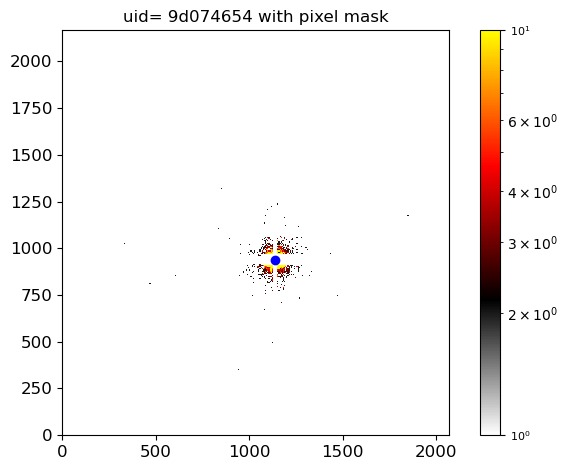

In [18]:
show_img(avg_img*pixel_mask*polygon_mask,vmin=1e-0,vmax=1e1, logs=True, 
         image_name= 'uid= %s with pixel mask'%uid , aspect=1, cmap= cmap_albula  )
for ii,i in enumerate(polygon_dict['masks']['hot_beam']['x_hots']):
    plt.plot(i+md['beam_center_x'],polygon_dict['masks']['hot_beam']['y_hots'][ii]+md['beam_center_y'],'b+')
plt.plot(md['beam_center_x'],md['beam_center_y'],'bo')

### Check SAXS analysis with detector and pixel mask -> stop the rotation galore!!

## try without rotations

Beam_center_x has been changed to 1137.0. (no change in raw metadata): 
Beam_center_y has been changed to 937.0.  (no change in raw metadata): 
uid--> uid=9d074654
dpix--> 0.075
Ldet--> 16033.390730000001
lambda_--> 1.2846772192850509
exposuretime--> 0.1
timeperframe--> 1.0
center--> [1137, 937]
path--> /nsls2/data/chx/legacy/analysis//2023_3/CHX staff/masks/


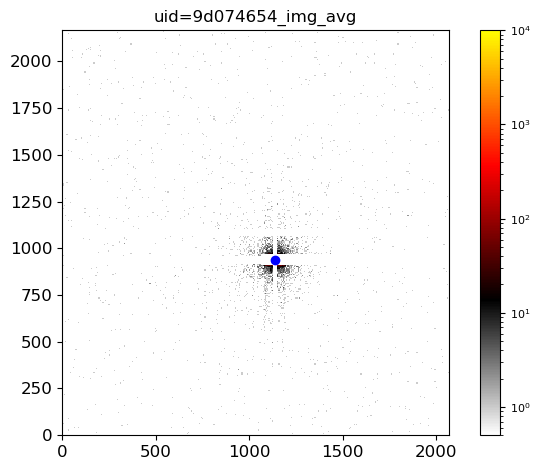

In [19]:
mask = np.array ( pixel_mask*polygon_mask , dtype = bool )
center= [ md['beam_center_x'], md['beam_center_y']]

#uidstr = 'uid=%s'%uid
# if md['detector'] =='eiger4m_single_image' or md['detector'] == 'image' or md['detector']=='eiger1m_single_image':    
#     inc_x0  = imgs[0].shape[0] -md['beam_center_y']   
#     inc_y0  = md['beam_center_x']   
# img_avg=avg_img[::-1]

dpix, lambda_, Ldet,  exposuretime, timeperframe, center = check_lost_metadata(
    md, Nimg, inc_x0 = center[1], inc_y0=   center[0], pixelsize = 7.5*10*(-5) )
setup_pargs=dict(uid='uid=%s'%uid, dpix= dpix, Ldet=Ldet, lambda_= lambda_, exposuretime=exposuretime,
        timeperframe=timeperframe, center=center[::-1], path= path)
print_dict( setup_pargs )
show_img( avg_img*mask,  vmin=.5, vmax= 1e4, logs=True, aspect=1, #save_format='tif',
         image_name= 'uid=%s'%uid + '_img_avg',  save=False, 
         path=path, center=center[::-1], cmap = cmap_albula ) 

/nsls2/users/lwiegart/.local/lib/python3.11/site-packages/pyCHX/XPCS_SAXS.py:537: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(ylim)


{'uid': 'uid=9d074654',
 'dpix': 0.075,
 'Ldet': 16033.390730000001,
 'lambda_': 1.2846772192850509,
 'exposuretime': 0.1,
 'timeperframe': 1.0,
 'center': [937, 1137],
 'path': '/nsls2/data/chx/legacy/analysis//2023_3/CHX staff/masks/'}

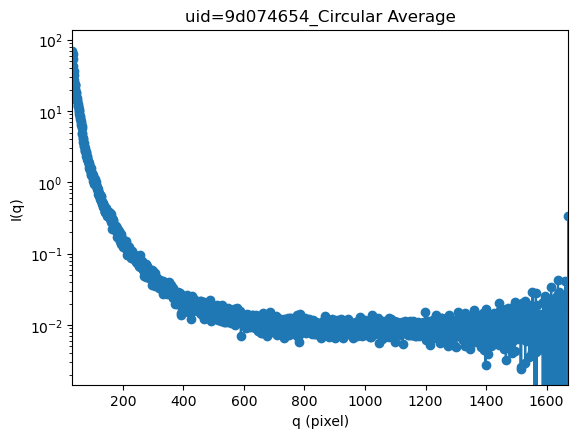

In [20]:
setup_pargs['center']=center
qp_saxs, iq_saxs, q_saxs = get_circular_average( avg_img*mask , mask , save=False,
                                                    pargs=setup_pargs  )
plot_circular_average( qp_saxs, iq_saxs, q_saxs,  pargs=setup_pargs,  show_pixel=True,
                      xlim=[qp_saxs.min(), qp_saxs.max()*1.0], ylim = [iq_saxs.min(), iq_saxs.max()*2],save=False)
setup_pargs

### Load an ROI mask

26


/nsls2/users/lwiegart/.local/lib/python3.11/site-packages/pyCHX/XPCS_SAXS.py:1556: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes.set_ylim(ylim)


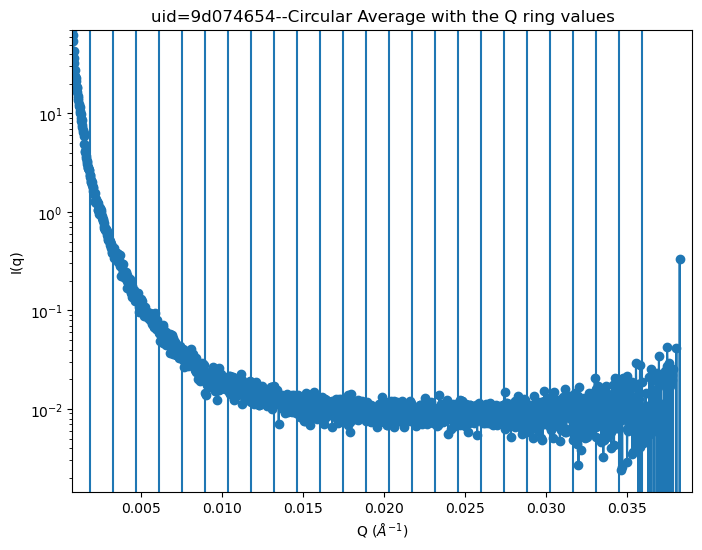

In [21]:
roi_mask_path = _mask_path_ + 'ROI_masks/'
roi_mask_norm = roi_mask_path + 'general_roi_mask_norm.json'
f = open(roi_mask_norm)  ### load json file
tmp = json.load(f);f.close()
mask_dict=json.loads(tmp);del tmp
roi_mask0 = np.array(mask_dict['roi_mask'])  
old_cen=mask_dict['original center'] 


setup_pargs['center']=center[::-1]
roi_mask, qval_dict, qwid_dict = get_roi_mask_qval_qwid_by_shift( 
                        new_cen=center, new_mask= mask, old_cen=old_cen,
                                    old_roi_mask=roi_mask0, limit_qnum= None,
                                    setup_pargs=setup_pargs, geometry = 'saxs',
                                    ) 


qr = np.array( [qval_dict[k][0] for k in sorted( qval_dict.keys())] )
try:
    qr_cal, qr_wid = get_QrQw_From_RoiMask( roi_mask, setup_pargs  ) 
    print(len(qr))         
    if (qr_cal - qr).sum() >=1e-3:
        print( 'The loaded ROI mask might not be applicable to this UID: %s.'%uid)
        print('Please check the loaded roi mask file.')
except:
    print('Something is wrong with the roi-mask. Please check the loaded roi mask file.')            
            
plot_qIq_with_ROI( q_saxs, iq_saxs, np.unique(qr), logs=True, uid='uid=%s'%uid, 
                  xlim=[q_saxs.min(), q_saxs.max()*1.02],#[0.0001,0.08],
                  ylim = [iq_saxs.min(), iq_saxs.max()*1.02],  save=False, path=path)
    
roi_mask = roi_mask * mask

### Save the polymask dictionary 

In [22]:
if False:
#if True:
    mask_filename = 'XPCS_beam_mask.json'
    gowrite=False
    if os.path.isfile(path+mask_filename): # file exists, check if overwriting is ok
        check = input(prompt='file %s exists. Overwrite existing file: y/n?'%(path+mask_filename))
        if check == 'y':
            gowrite = True
        else: print('DATA NOT WRITTEN TO FILE!')
    else: gowrite =True
    if gowrite:
        with open(path+mask_filename, "w") as outfile:
            json.dump(polygon_dict, outfile)
            print('metadata has been written to %s'%path+mask_filename)